# Dataset A 3-Class Baselines with Strict LORO-CV

This notebook benchmarks the Dataset A under a strict 3-class protocol using leave-one-run-out cross-validation (LORO-CV).

Protocol enforced here:
- Input: data/processed/dataset_A_pruned.csv
- Apply run-3 split if needed (partA/partB)
- Keep labels only: dry_dirt_track, grass, smooth_terrain
- Drop run: log_20260223_142511.490
- Final run list must be exactly 4 runs
- KNOWN_DEGENERATE mapping is fail-fast checked per fold
- LabelEncoder fit on train labels only (per fold)
- StandardScaler is inside each model pipeline

This notebook is benchmark-only and intentionally does not retrain a final deployment model.

In [4]:
from __future__ import annotations

import json
import warnings
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_recall_fscore_support
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

try:
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError("xgboost is required for this notebook.") from exc

cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "src").exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RANDOM_STATE = 42
N_TOP_MI = 25
ENABLE_FOLD_LOCAL_TOP_MI = True
MI_NEIGHBORS = 5
RUN_IMBALANCE_COMPARISON = True
N_PERMUTATION_REPEATS = 8
CLASS_SAMPLE_WARN_THRESHOLD = 30

DATASET_PATH = PROJECT_ROOT / "data" / "processed" / "dataset_A_pruned.csv"
TOP_MI_PATH = PROJECT_ROOT / "data" / "processed" / "top_mi_features.json"
RESULTS_DIR = PROJECT_ROOT / "results"
REPORTS_DIR = PROJECT_ROOT / "reports" / "models"

for out_dir in [RESULTS_DIR, REPORTS_DIR]:
    out_dir.mkdir(parents=True, exist_ok=True)

LABEL_COL = "label"
RUN_COL = "run_id"
ID_COLS = [
    "window_id",
    "run_id",
    "segment_id",
    "label",
    "t_start",
    "t_end",
    "n_samples",
]
LABEL_ORDER = ["dry_dirt_track", "grass", "smooth_terrain"]

RUN3_ID = "log_20260309_141435.414"
EXCLUDED_RUN = "log_20260223_142511.490"
FINAL_RUNS = [
    "log_20260226_102148.990",
    "log_20260309_141435.414_partA",
    "log_20260309_141435.414_partB",
    "log_20260326_120021.508",
]
KNOWN_DEGENERATE = {
    "log_20260226_102148.990": [],
    "log_20260309_141435.414_partA": [],
    "log_20260309_141435.414_partB": [],
    "log_20260326_120021.508": [],
}

print("Configuration loaded for Dataset A 3-class benchmark")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
from src.evaluation import (
    compute_fold_metrics,
    fmt_mean_std,
    make_base_models,
    row_normalize,
    summarize_group,
)


Configuration loaded for Dataset A 3-class benchmark
PROJECT_ROOT: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis


In [5]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Missing dataset: {DATASET_PATH}")
if not TOP_MI_PATH.exists():
    raise FileNotFoundError(f"Missing MI feature list: {TOP_MI_PATH}")

df = pd.read_csv(DATASET_PATH)

if RUN3_ID in set(df[RUN_COL].astype(str)):
    run3 = df[df[RUN_COL] == RUN3_ID].sort_values("t_start")
    midpoint = run3["t_start"].median()
    df.loc[(df[RUN_COL] == RUN3_ID) & (df["t_start"] <= midpoint), RUN_COL] = f"{RUN3_ID}_partA"
    df.loc[(df[RUN_COL] == RUN3_ID) & (df["t_start"] > midpoint), RUN_COL] = f"{RUN3_ID}_partB"

df = df[df[LABEL_COL].isin(LABEL_ORDER)].copy()
df = df[df[RUN_COL].astype(str) != EXCLUDED_RUN].copy()

with TOP_MI_PATH.open("r", encoding="utf-8") as f:
    top_mi_raw = json.load(f)

if isinstance(top_mi_raw, dict):
    if "top_features" in top_mi_raw and isinstance(top_mi_raw["top_features"], list):
        top_mi_features = list(top_mi_raw["top_features"])
    else:
        top_mi_features = list(top_mi_raw.keys())
elif isinstance(top_mi_raw, list):
    top_mi_features = list(top_mi_raw)
else:
    raise ValueError("Unsupported top_mi_features.json structure.")

missing_id_cols = [c for c in ID_COLS if c not in df.columns]
if missing_id_cols:
    raise KeyError(f"Missing ID columns in dataset: {missing_id_cols}")

labels_found = sorted(df[LABEL_COL].astype(str).unique().tolist())
if labels_found != sorted(LABEL_ORDER):
    raise ValueError(f"Label check failed. Expected {sorted(LABEL_ORDER)} got {labels_found}")

run_ids = sorted(df[RUN_COL].astype(str).unique().tolist())
if run_ids != sorted(FINAL_RUNS):
    raise ValueError(
        f"Final run list mismatch. Expected {sorted(FINAL_RUNS)} got {run_ids}."
    )

if set(run_ids) != set(KNOWN_DEGENERATE.keys()):
    raise ValueError("KNOWN_DEGENERATE keys must match final run IDs exactly.")

feature_cols_all = [c for c in df.columns if c not in ID_COLS]
feature_cols_top_mi_seed = [c for c in top_mi_features if c in feature_cols_all]
if not feature_cols_top_mi_seed:
    raise ValueError("No overlap between top_mi_features.json and dataset columns.")

speed_cols = [c for c in ["odom_mean_speed", "odom_speed_std", "odom_distance", "net_speed"] if c in feature_cols_all]
feature_cols_all_no_speed = [c for c in feature_cols_all if c not in set(speed_cols)]
if not feature_cols_all_no_speed:
    raise ValueError("all_no_speed feature set became empty.")

feature_sets = {
    "all": feature_cols_all,
    "all_no_speed": feature_cols_all_no_speed,
    "top_mi": feature_cols_top_mi_seed[:N_TOP_MI],
}

print(f"Dataset shape after filtering: {df.shape}")
print(f"Runs ({len(run_ids)}): {run_ids}")
print("Run x label distribution:")
print(df.groupby(RUN_COL)[LABEL_COL].value_counts().unstack(fill_value=0).to_string())
print(f"Feature counts - all: {len(feature_cols_all)}, all_no_speed: {len(feature_cols_all_no_speed)}, top_mi_seed: {len(feature_sets['top_mi'])}")

Dataset shape after filtering: (1652, 130)
Runs (4): ['log_20260226_102148.990', 'log_20260309_141435.414_partA', 'log_20260309_141435.414_partB', 'log_20260326_120021.508']
Run x label distribution:
label                          dry_dirt_track  grass  smooth_terrain
run_id                                                              
log_20260226_102148.990                     0     44              55
log_20260309_141435.414_partA             394     68             202
log_20260309_141435.414_partB             258    248             121
log_20260326_120021.508                     0    102             160
Feature counts - all: 123, all_no_speed: 120, top_mi_seed: 9


In [6]:
def build_model_variants(run_imbalance_comparison: bool = True) -> list[dict[str, object]]:
    variants: list[dict[str, object]] = []
    for model_name, pipeline in make_base_models(RANDOM_STATE).items():
        variants.append(
            {
                "variant_name": f"{model_name}_unweighted",
                "base_model": model_name,
                "imbalance": "unweighted",
                "pipeline": clone(pipeline),
                "requires_encoded_labels": model_name == "XGBoost",
                "needs_sample_weight": False,
            }
        )

        if run_imbalance_comparison:
            balanced_pipe = clone(pipeline)
            needs_sample_weight = False
            if model_name in {"LogisticRegression", "RandomForest", "SVM"}:
                balanced_pipe.set_params(clf__class_weight="balanced")
            elif model_name == "XGBoost":
                needs_sample_weight = True

            variants.append(
                {
                    "variant_name": f"{model_name}_balanced",
                    "base_model": model_name,
                    "imbalance": "balanced",
                    "pipeline": balanced_pipe,
                    "requires_encoded_labels": model_name == "XGBoost",
                    "needs_sample_weight": needs_sample_weight,
                }
            )
    return variants


def fold_local_top_mi_features(
    train_df: pd.DataFrame,
    y_train: np.ndarray,
    pool_cols: list[str],
    n_top: int,
    n_neighbors: int,
    random_state: int,
    fallback_cols: list[str],
) -> list[str]:
    X_pool = np.nan_to_num(train_df[pool_cols].to_numpy(dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
    if X_pool.shape[1] == 0:
        return list(fallback_cols)
    scores = mutual_info_classif(
        X_pool,
        y_train,
        n_neighbors=n_neighbors,
        random_state=random_state,
    )
    ranked_idx = np.argsort(scores)[::-1]
    selected = [pool_cols[i] for i in ranked_idx[: min(n_top, len(pool_cols))]]
    return selected if selected else list(fallback_cols)


model_variants = build_model_variants(run_imbalance_comparison=RUN_IMBALANCE_COMPARISON)
print(f"Model variants: {[v['variant_name'] for v in model_variants]}")

Model variants: ['LogisticRegression_unweighted', 'LogisticRegression_balanced', 'RandomForest_unweighted', 'RandomForest_balanced', 'XGBoost_unweighted', 'XGBoost_balanced', 'SVM_unweighted', 'SVM_balanced']


In [7]:
detail_rows: list[dict[str, object]] = []
per_class_rows: list[dict[str, object]] = []
confusion_records: list[dict[str, object]] = []
fold_top_mi_rows: list[dict[str, object]] = []
feature_importance_store: dict[tuple[str, str, str], list[pd.Series]] = {}
permutation_importance_store: dict[tuple[str, str, str], list[pd.Series]] = {}
lr_coef_store: dict[tuple[str, str], list[pd.DataFrame]] = {}

for feature_set_name, base_feature_cols in feature_sets.items():
    for test_run in run_ids:
        train_mask = df[RUN_COL].astype(str) != test_run
        test_mask = ~train_mask

        train_df = df.loc[train_mask].copy()
        test_df = df.loc[test_mask].copy()

        y_train = train_df[LABEL_COL].astype(str).to_numpy()
        y_test = test_df[LABEL_COL].astype(str).to_numpy()

        observed_missing_from_train = sorted(set(y_test) - set(y_train))
        expected_missing = sorted(KNOWN_DEGENERATE[test_run])
        if observed_missing_from_train != expected_missing:
            raise ValueError(
                f"KNOWN_DEGENERATE mismatch for {test_run}. Expected {expected_missing}, observed {observed_missing_from_train}."
            )

        selected_feature_cols = list(base_feature_cols)
        if feature_set_name == "top_mi" and ENABLE_FOLD_LOCAL_TOP_MI:
            selected_feature_cols = fold_local_top_mi_features(
                train_df=train_df,
                y_train=y_train,
                pool_cols=feature_cols_all,
                n_top=N_TOP_MI,
                n_neighbors=MI_NEIGHBORS,
                random_state=RANDOM_STATE,
                fallback_cols=feature_sets["top_mi"],
            )
            fold_top_mi_rows.append(
                {
                    "test_run": test_run,
                    "n_features": int(len(selected_feature_cols)),
                    "selected_features": "|".join(selected_feature_cols),
                }
            )

        X_train = train_df[selected_feature_cols]
        X_test = test_df[selected_feature_cols]

        le = LabelEncoder()
        y_train_encoded = le.fit_transform(y_train)
        encoder_map = {label: idx for idx, label in enumerate(le.classes_)}
        y_test_encoded = np.array([encoder_map.get(label, -1) for label in y_test], dtype=int)
        if np.any(y_test_encoded < 0):
            raise ValueError(f"Unexpected unseen test label in fold {test_run}.")

        for variant in model_variants:
            pipeline = clone(variant["pipeline"])
            base_model = str(variant["base_model"])
            imbalance = str(variant["imbalance"])
            variant_name = str(variant["variant_name"])

            fit_kwargs = {}
            if bool(variant["needs_sample_weight"]):
                fit_kwargs["clf__sample_weight"] = compute_sample_weight("balanced", y_train_encoded)

            if bool(variant["requires_encoded_labels"]):
                pipeline.fit(X_train, y_train_encoded, **fit_kwargs)
                y_pred_encoded = np.asarray(pipeline.predict(X_test), dtype=int)
                y_pred = le.inverse_transform(y_pred_encoded)
                y_perm_target = y_test_encoded
            else:
                pipeline.fit(X_train, y_train)
                y_pred = np.asarray(pipeline.predict(X_test), dtype=object)
                y_perm_target = y_test

            evaluable_classes = sorted(set(y_train).intersection(set(y_test)))
            fold_metrics = compute_fold_metrics(
                y_true=y_test,
                y_pred=y_pred,
                evaluable_classes=evaluable_classes,
                label_order=LABEL_ORDER,
            )

            detail_rows.append(
                {
                    "model": base_model,
                    "feature_set": feature_set_name,
                    "imbalance": imbalance,
                    "test_run": test_run,
                    "n_test": fold_metrics["n_test"],
                    "n_features": int(len(selected_feature_cols)),
                    "accuracy": fold_metrics["accuracy"],
                    "macro_f1": fold_metrics["macro_f1"],
                    "degenerate_classes": "None",
                }
            )

            confusion_records.append(
                {
                    "model": base_model,
                    "feature_set": feature_set_name,
                    "imbalance": imbalance,
                    "test_run": test_run,
                    "y_true": y_test.copy(),
                    "y_pred": y_pred.copy(),
                    "degenerate_classes": expected_missing,
                }
            )

            for cls_name in LABEL_ORDER:
                cls_metrics = fold_metrics["per_class"][cls_name]
                per_class_rows.append(
                    {
                        "model": base_model,
                        "feature_set": feature_set_name,
                        "imbalance": imbalance,
                        "test_run": test_run,
                        "class": cls_name,
                        "precision": cls_metrics["precision"],
                        "recall": cls_metrics["recall"],
                        "f1": cls_metrics["f1"],
                        "support": cls_metrics["support"],
                    }
                )

            try:
                perm_result = permutation_importance(
                    estimator=pipeline,
                    X=X_test,
                    y=y_perm_target,
                    scoring="f1_macro",
                    n_repeats=N_PERMUTATION_REPEATS,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                )
                perm_series = pd.Series(perm_result.importances_mean, index=selected_feature_cols, dtype=float)
                permutation_importance_store.setdefault((base_model, feature_set_name, imbalance), []).append(perm_series)
            except Exception as exc:
                warnings.warn(
                    f"Permutation importance failed for {variant_name} on {test_run} ({feature_set_name}): {exc}"
                )

            clf = pipeline.named_steps["clf"]
            if base_model in {"RandomForest", "XGBoost"} and hasattr(clf, "feature_importances_"):
                imp = pd.Series(clf.feature_importances_, index=selected_feature_cols, dtype=float)
                feature_importance_store.setdefault((base_model, feature_set_name, imbalance), []).append(imp)
            elif base_model == "LogisticRegression":
                coef_df = pd.DataFrame(clf.coef_, index=clf.classes_, columns=selected_feature_cols)
                lr_coef_store.setdefault((feature_set_name, imbalance), []).append(coef_df)

            print(
                f"Fold={test_run} | {variant_name} | feature_set={feature_set_name} | n_feat={len(selected_feature_cols)} | "
                f"acc={fold_metrics['accuracy']:.3f} | macro_f1={fold_metrics['macro_f1']:.3f}"
            )

if fold_top_mi_rows:
    fold_top_mi_df = pd.DataFrame(fold_top_mi_rows)
    fold_top_mi_out = RESULTS_DIR / "dataset_A_3class_fold_local_top_mi_features.csv"
    fold_top_mi_df.to_csv(fold_top_mi_out, index=False)
    print(f"Saved: {fold_top_mi_out}")

print("LORO evaluation complete.")

Fold=log_20260226_102148.990 | LogisticRegression_unweighted | feature_set=all | n_feat=123 | acc=0.990 | macro_f1=0.995
Fold=log_20260226_102148.990 | LogisticRegression_balanced | feature_set=all | n_feat=123 | acc=1.000 | macro_f1=1.000
Fold=log_20260226_102148.990 | RandomForest_unweighted | feature_set=all | n_feat=123 | acc=0.990 | macro_f1=0.995
Fold=log_20260226_102148.990 | RandomForest_balanced | feature_set=all | n_feat=123 | acc=0.980 | macro_f1=0.990
Fold=log_20260226_102148.990 | XGBoost_unweighted | feature_set=all | n_feat=123 | acc=1.000 | macro_f1=1.000
Fold=log_20260226_102148.990 | XGBoost_balanced | feature_set=all | n_feat=123 | acc=1.000 | macro_f1=1.000
Fold=log_20260226_102148.990 | SVM_unweighted | feature_set=all | n_feat=123 | acc=1.000 | macro_f1=1.000
Fold=log_20260226_102148.990 | SVM_balanced | feature_set=all | n_feat=123 | acc=1.000 | macro_f1=1.000
Fold=log_20260309_141435.414_partA | LogisticRegression_unweighted | feature_set=all | n_feat=123 | acc=

In [8]:
detail_df = pd.DataFrame(detail_rows)
if detail_df.empty:
    raise RuntimeError("No fold results were produced.")

detail_df = detail_df[[
    "model",
    "feature_set",
    "imbalance",
    "test_run",
    "n_test",
    "n_features",
    "accuracy",
    "macro_f1",
    "degenerate_classes",
]]

summary_df = (
    detail_df.groupby(["model", "feature_set", "imbalance"], as_index=False)
    .apply(summarize_group)
    .reset_index(drop=True)
)
summary_ranked = summary_df.sort_values("robustness_score", ascending=False).reset_index(drop=True)

detail_out = RESULTS_DIR / "dataset_A_3class_metrics_per_fold.csv"
summary_out = RESULTS_DIR / "dataset_A_3class_metrics_summary.csv"
ranking_out = RESULTS_DIR / "dataset_A_3class_metrics_ranked_by_robustness.csv"

detail_df.to_csv(detail_out, index=False)
summary_df.to_csv(summary_out, index=False)
summary_ranked.to_csv(ranking_out, index=False)

print("Per-fold results:")
print(detail_df.to_string(index=False))
print("\nAggregated summary:")
print(summary_df.to_string(index=False))
print(f"Saved: {detail_out}")
print(f"Saved: {summary_out}")
print(f"Saved: {ranking_out}")

Per-fold results:
             model  feature_set  imbalance                      test_run  n_test  n_features  accuracy  macro_f1 degenerate_classes
LogisticRegression          all unweighted       log_20260226_102148.990      99         123  0.989899  0.995413               None
LogisticRegression          all   balanced       log_20260226_102148.990      99         123  1.000000  1.000000               None
      RandomForest          all unweighted       log_20260226_102148.990      99         123  0.989899  0.995413               None
      RandomForest          all   balanced       log_20260226_102148.990      99         123  0.979798  0.989666               None
           XGBoost          all unweighted       log_20260226_102148.990      99         123  1.000000  1.000000               None
           XGBoost          all   balanced       log_20260226_102148.990      99         123  1.000000  1.000000               None
               SVM          all unweighted       log_20260

Best imbalance by model (feature_set=all):
{'LogisticRegression': 'balanced', 'RandomForest': 'unweighted', 'SVM': 'balanced', 'XGBoost': 'balanced'}


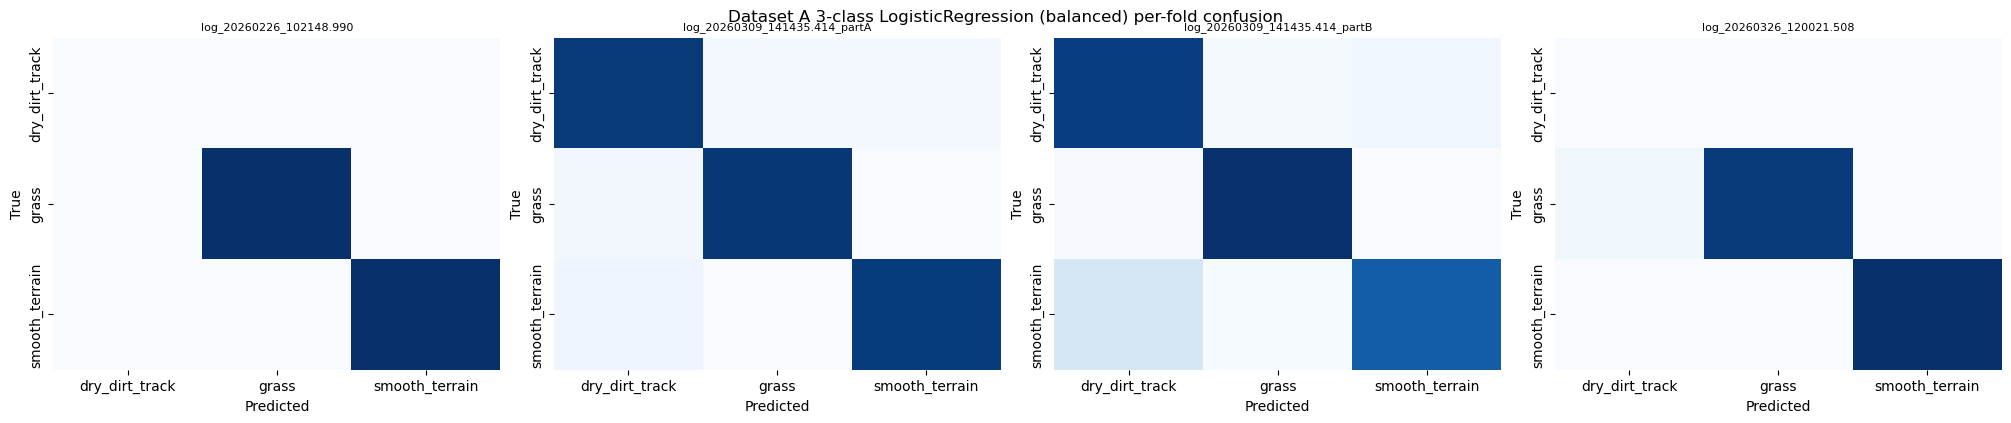

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/dataset_A_3class_confusion_matrix_logisticregression_per_fold.png


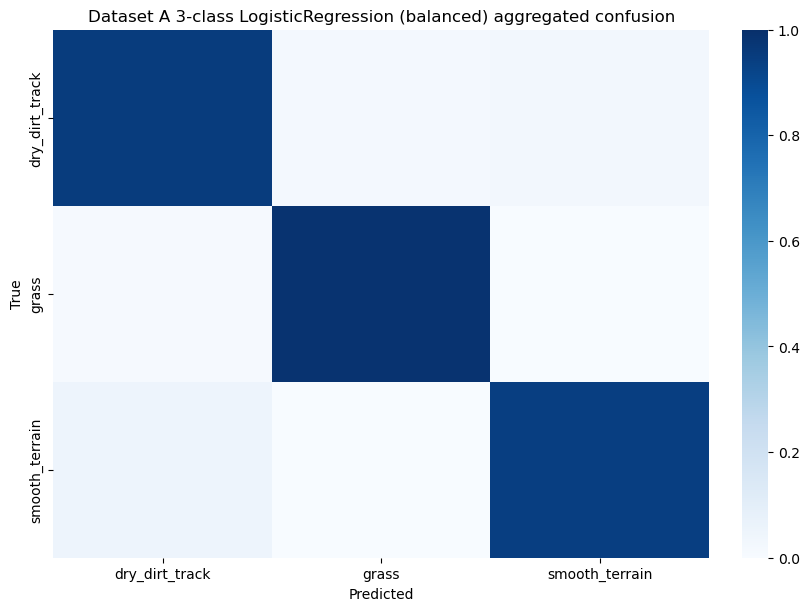

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/dataset_A_3class_confusion_matrix_logisticregression_aggregated.png


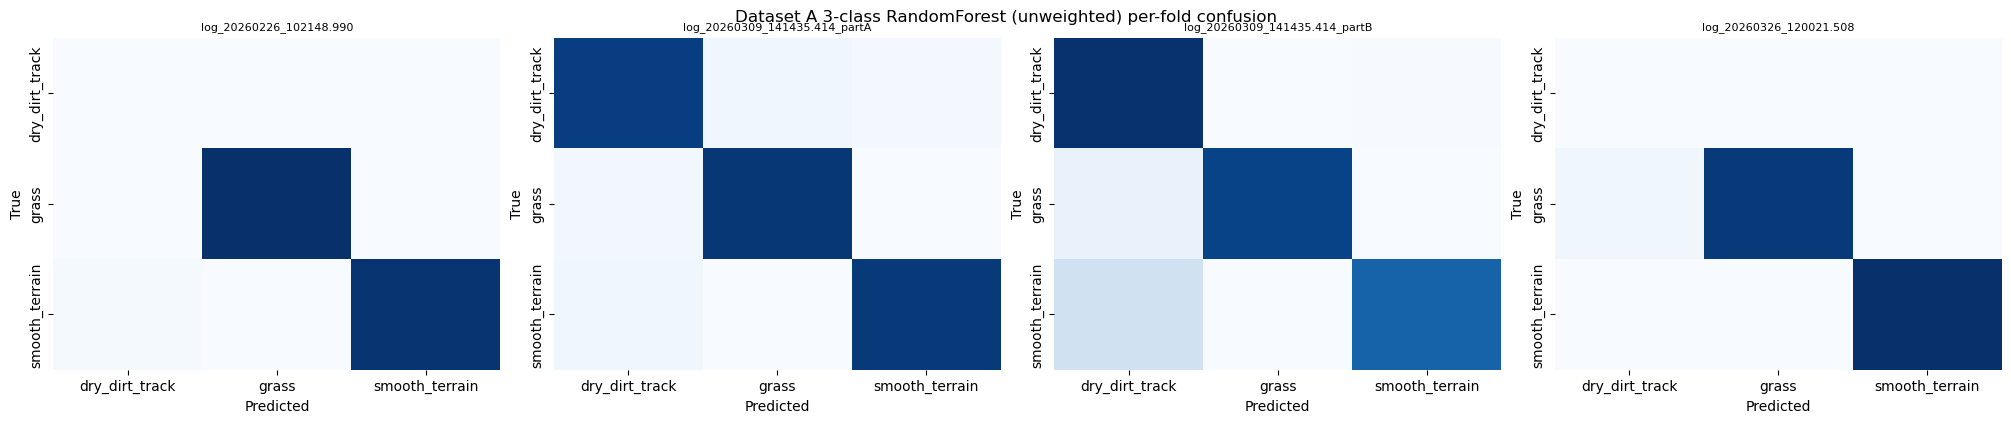

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/dataset_A_3class_confusion_matrix_randomforest_per_fold.png


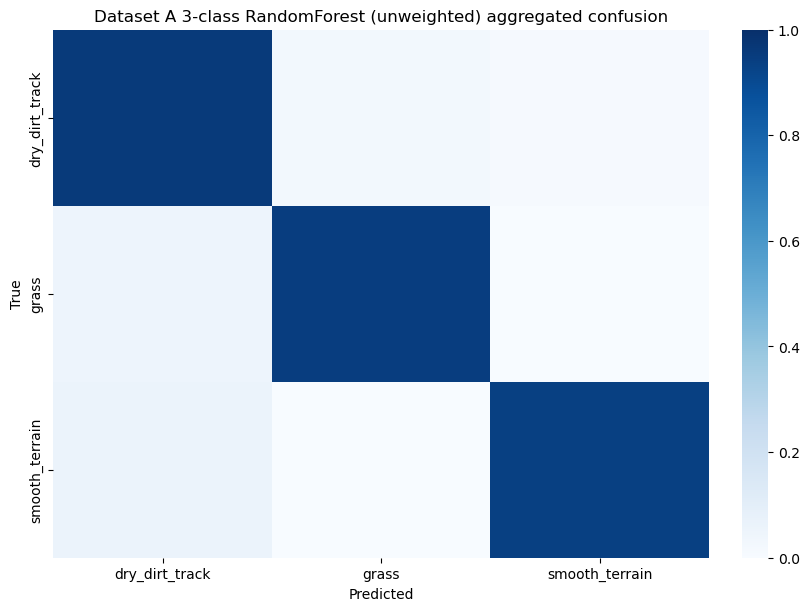

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/dataset_A_3class_confusion_matrix_randomforest_aggregated.png


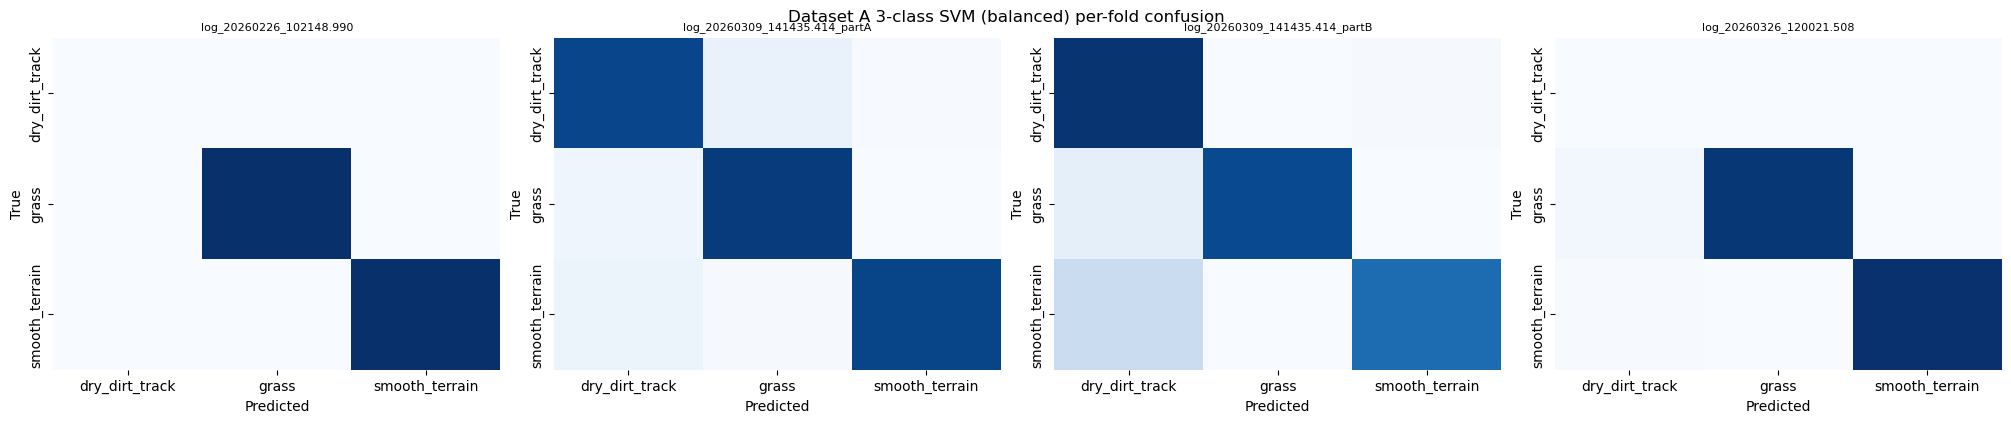

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/dataset_A_3class_confusion_matrix_svm_per_fold.png


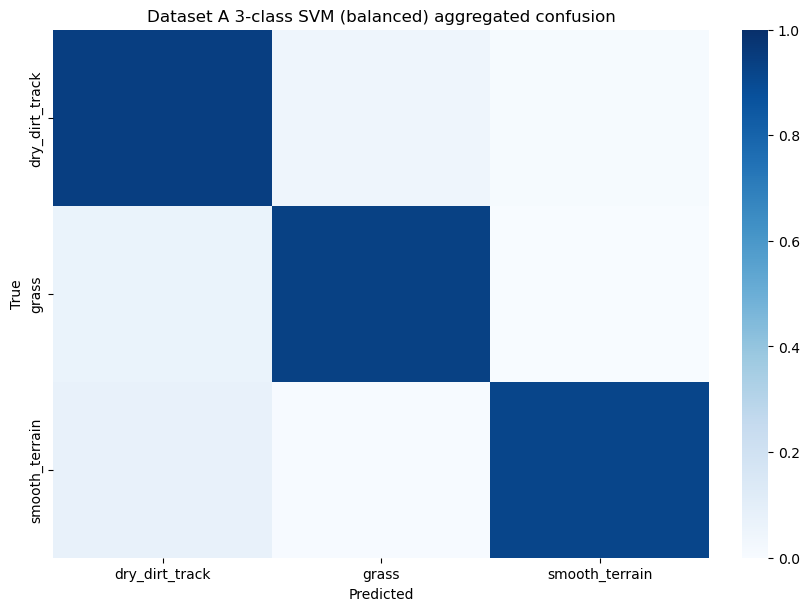

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/dataset_A_3class_confusion_matrix_svm_aggregated.png


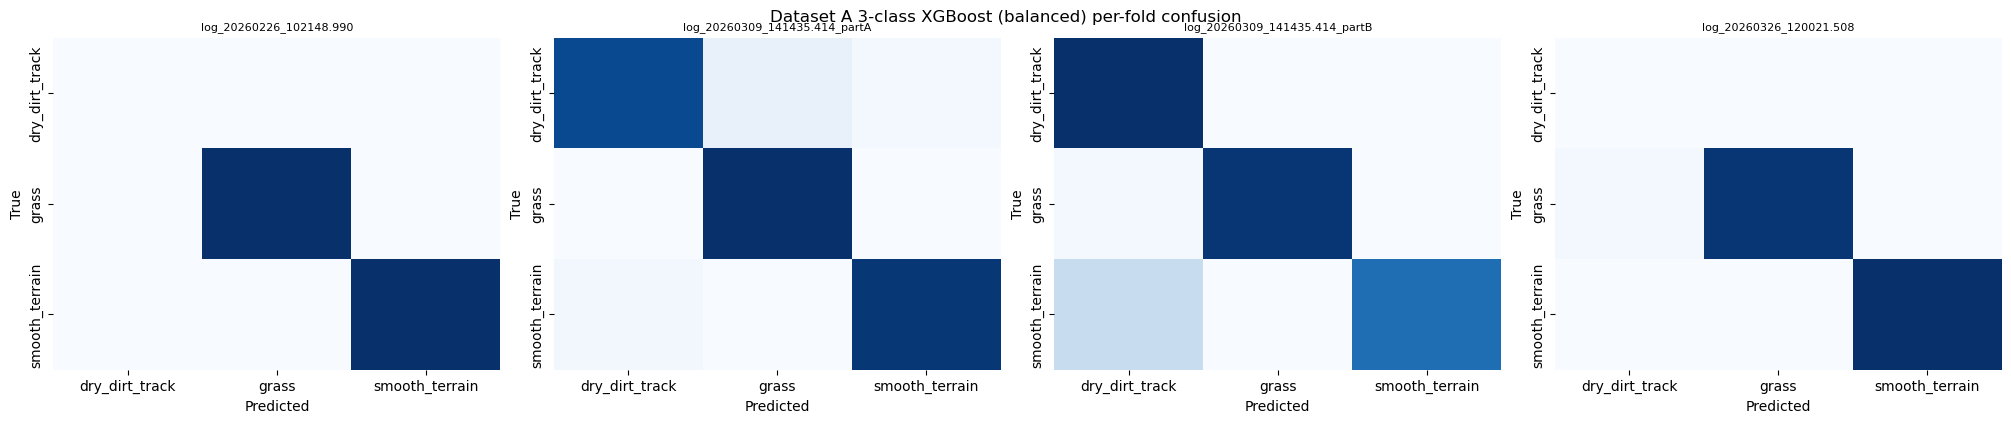

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/dataset_A_3class_confusion_matrix_xgboost_per_fold.png


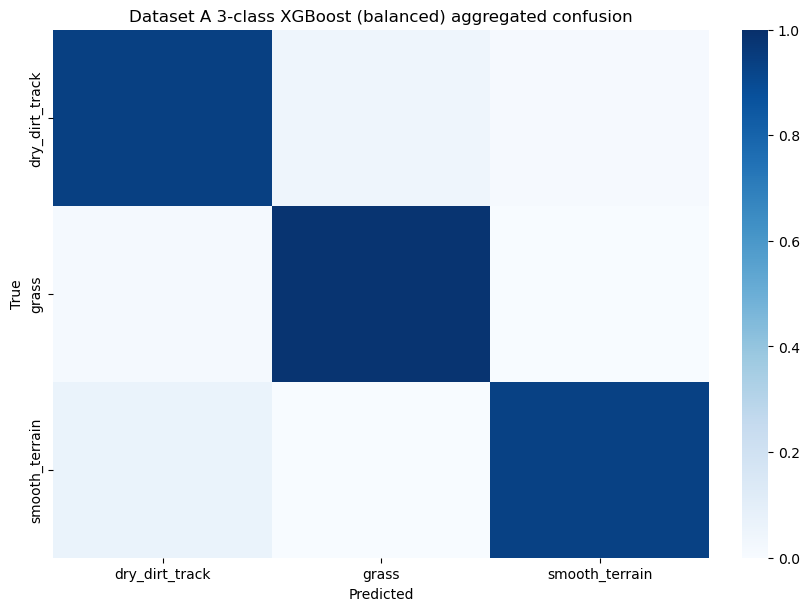

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/dataset_A_3class_confusion_matrix_xgboost_aggregated.png


In [9]:
all_feature_summary = summary_df[summary_df["feature_set"] == "all"].copy()
if all_feature_summary.empty:
    raise RuntimeError("No all-feature summary rows found for confusion plotting.")

best_imbalance_by_model: dict[str, str] = {}
for model_name in sorted(all_feature_summary["model"].unique().tolist()):
    sub = all_feature_summary[all_feature_summary["model"] == model_name].sort_values("macro_f1_mean", ascending=False)
    best_imbalance_by_model[model_name] = str(sub.iloc[0]["imbalance"])

print("Best imbalance by model (feature_set=all):")
print(best_imbalance_by_model)

for model_name, best_imbalance in best_imbalance_by_model.items():
    recs = [
        r
        for r in confusion_records
        if r["model"] == model_name and r["feature_set"] == "all" and r["imbalance"] == best_imbalance
    ]
    if not recs:
        continue

    fig, axes = plt.subplots(1, len(run_ids), figsize=(5 * len(run_ids), 4), constrained_layout=True)
    if len(run_ids) == 1:
        axes = [axes]

    agg_raw = np.zeros((len(LABEL_ORDER), len(LABEL_ORDER)), dtype=int)

    for idx, test_run in enumerate(run_ids):
        ax = axes[idx]
        rec = next((r for r in recs if r["test_run"] == test_run), None)
        if rec is None:
            ax.axis("off")
            continue

        cm_raw = confusion_matrix(rec["y_true"], rec["y_pred"], labels=LABEL_ORDER)
        agg_raw += cm_raw
        cm_norm = row_normalize(cm_raw)

        sns.heatmap(
            cm_norm,
            ax=ax,
            cmap="Blues",
            vmin=0,
            vmax=1,
            xticklabels=LABEL_ORDER,
            yticklabels=LABEL_ORDER,
            cbar=False,
        )
        ax.set_title(test_run, fontsize=8)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    per_fold_path = REPORTS_DIR / f"dataset_A_3class_confusion_matrix_{model_name.lower()}_per_fold.png"
    fig.suptitle(f"Dataset A 3-class {model_name} ({best_imbalance}) per-fold confusion", y=1.02)
    fig.savefig(per_fold_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {per_fold_path}")

    agg_norm = row_normalize(agg_raw)
    fig_agg, ax_agg = plt.subplots(figsize=(8, 6), constrained_layout=True)
    sns.heatmap(
        agg_norm,
        ax=ax_agg,
        cmap="Blues",
        vmin=0,
        vmax=1,
        xticklabels=LABEL_ORDER,
        yticklabels=LABEL_ORDER,
        cbar=True,
    )
    ax_agg.set_title(f"Dataset A 3-class {model_name} ({best_imbalance}) aggregated confusion")
    ax_agg.set_xlabel("Predicted")
    ax_agg.set_ylabel("True")

    support_rows = agg_raw.sum(axis=1).astype(int)
    for row_idx, support in enumerate(support_rows):
        if support < CLASS_SAMPLE_WARN_THRESHOLD:
            ax_agg.text(
                len(LABEL_ORDER) - 0.05,
                row_idx + 0.5,
                f"n={support}",
                ha="right",
                va="center",
                color="black",
                fontsize=9,
                bbox={"facecolor": "white", "alpha": 0.7, "edgecolor": "none"},
            )

    agg_path = REPORTS_DIR / f"dataset_A_3class_confusion_matrix_{model_name.lower()}_aggregated.png"
    fig_agg.savefig(agg_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {agg_path}")


Per-class metrics for LogisticRegression (balanced, all features):
         Class       Precision          Recall              F1  F1 median   F1 min   F1 max Folds evaluated Flag
dry_dirt_track 0.946 +/- 0.026 0.951 +/- 0.009 0.948 +/- 0.017   0.948276 0.931034 0.965517             2/4 WARN
         grass 0.967 +/- 0.044 0.982 +/- 0.017 0.974 +/- 0.027   0.983014 0.929577 1.000000             4/4     
smooth_terrain 0.967 +/- 0.037 0.945 +/- 0.071 0.956 +/- 0.055   0.978908 0.865801 1.000000             4/4     
Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/results/dataset_A_3class_per_class_metrics_logisticregression.csv

Per-class metrics for RandomForest (unweighted, all features):
         Class       Precision          Recall              F1  F1 median   F1 min   F1 max Folds evaluated Flag
dry_dirt_track 0.916 +/- 0.058 0.965 +/- 0.023 0.938 +/- 0.019   0.938169 0.918919 0.957419             2/4 WARN
         grass 0.953 +/- 0.080 0.965

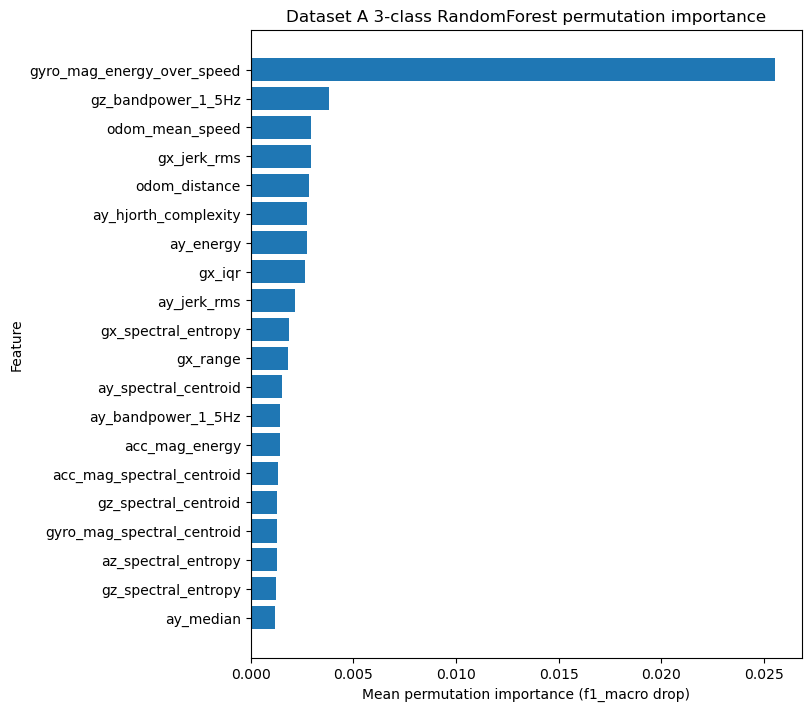

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/dataset_A_3class_feature_importance_permutation_randomforest.png


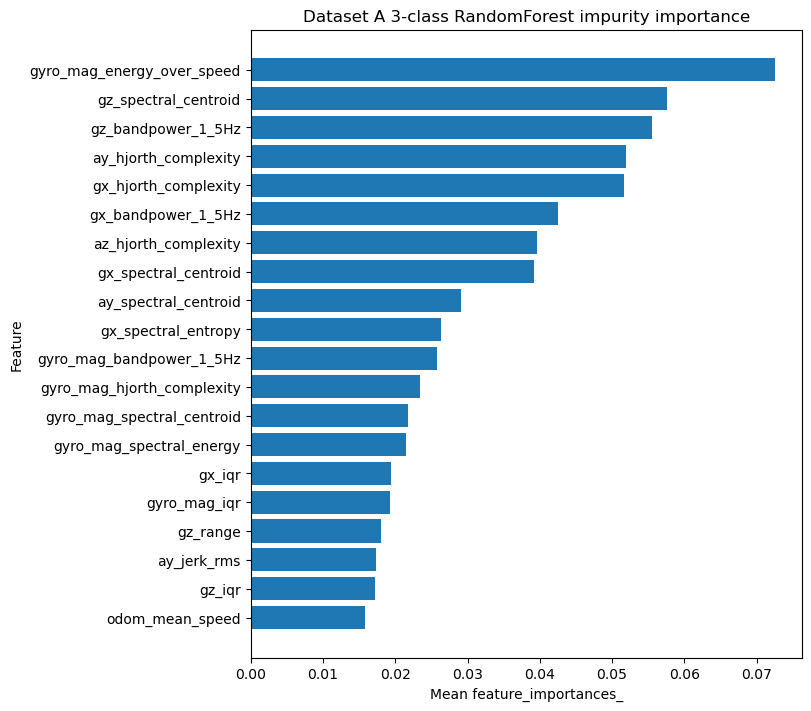

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/dataset_A_3class_feature_importance_impurity_randomforest.png


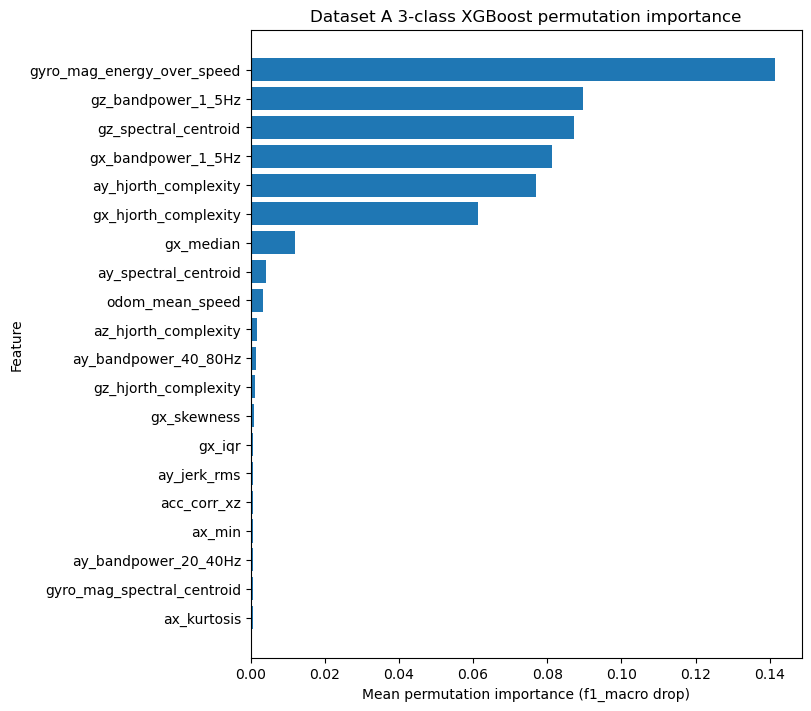

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/dataset_A_3class_feature_importance_permutation_xgboost.png


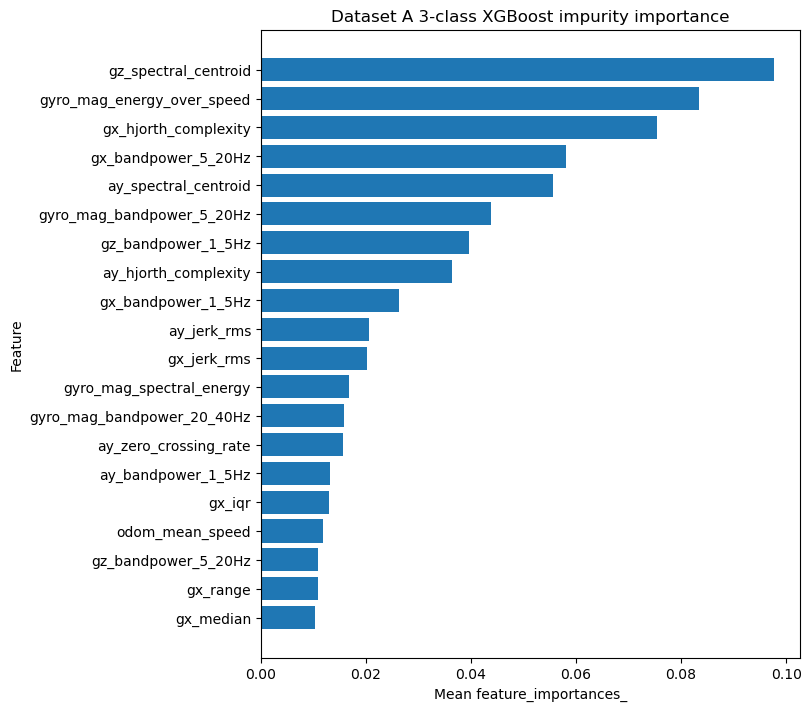

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/dataset_A_3class_feature_importance_impurity_xgboost.png


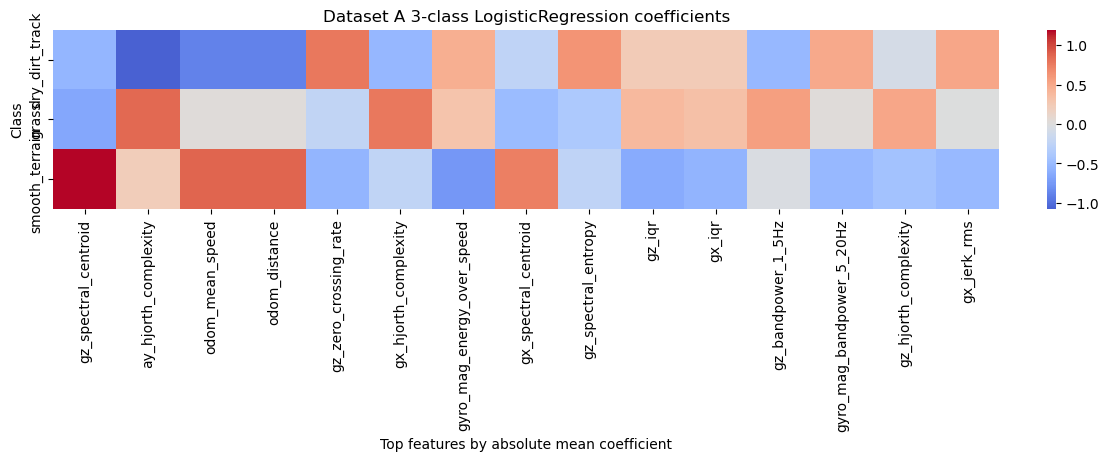

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/models/dataset_A_3class_feature_importance_lr_coefficients.png
Top-10 permutation overlap between RF and XGB:
['ay_hjorth_complexity', 'gyro_mag_energy_over_speed', 'gz_bandpower_1_5Hz', 'odom_mean_speed']


In [10]:
per_class_df = pd.DataFrame(per_class_rows)
if per_class_df.empty:
    raise RuntimeError("Per-class metrics were not collected.")

for model_name, best_imbalance in best_imbalance_by_model.items():
    sub = per_class_df[
        (per_class_df["model"] == model_name)
        & (per_class_df["feature_set"] == "all")
        & (per_class_df["imbalance"] == best_imbalance)
    ].copy()

    rows = []
    for cls_name in LABEL_ORDER:
        cls_sub = sub[sub["class"] == cls_name]
        f1_vals = cls_sub["f1"].dropna()
        folds_eval = int(f1_vals.shape[0])
        rows.append(
            {
                "Class": cls_name,
                "Precision": fmt_mean_std(cls_sub["precision"]),
                "Recall": fmt_mean_std(cls_sub["recall"]),
                "F1": fmt_mean_std(cls_sub["f1"]),
                "F1 median": float(f1_vals.median()) if not f1_vals.empty else np.nan,
                "F1 min": float(f1_vals.min()) if not f1_vals.empty else np.nan,
                "F1 max": float(f1_vals.max()) if not f1_vals.empty else np.nan,
                "Folds evaluated": f"{folds_eval}/{len(run_ids)}",
                "Flag": "WARN" if folds_eval < len(run_ids) else "",
                "precision_mean": cls_sub["precision"].mean(skipna=True),
                "precision_std": cls_sub["precision"].std(ddof=0, skipna=True),
                "recall_mean": cls_sub["recall"].mean(skipna=True),
                "recall_std": cls_sub["recall"].std(ddof=0, skipna=True),
                "f1_mean": cls_sub["f1"].mean(skipna=True),
                "f1_std": cls_sub["f1"].std(ddof=0, skipna=True),
                "f1_median": float(f1_vals.median()) if not f1_vals.empty else np.nan,
                "f1_min": float(f1_vals.min()) if not f1_vals.empty else np.nan,
                "f1_max": float(f1_vals.max()) if not f1_vals.empty else np.nan,
                "folds_evaluated": folds_eval,
            }
        )

    pretty = pd.DataFrame(rows)[[
        "Class",
        "Precision",
        "Recall",
        "F1",
        "F1 median",
        "F1 min",
        "F1 max",
        "Folds evaluated",
        "Flag",
    ]]
    print(f"\nPer-class metrics for {model_name} ({best_imbalance}, all features):")
    print(pretty.to_string(index=False))

    export_df = pd.DataFrame(rows)[[
        "Class",
        "precision_mean",
        "precision_std",
        "recall_mean",
        "recall_std",
        "f1_mean",
        "f1_std",
        "f1_median",
        "f1_min",
        "f1_max",
        "folds_evaluated",
        "Flag",
    ]]
    out = RESULTS_DIR / f"dataset_A_3class_per_class_metrics_{model_name.lower()}.csv"
    export_df.to_csv(out, index=False)
    print(f"Saved: {out}")

top10_by_model: dict[str, list[str]] = {}
for model_name in ["RandomForest", "XGBoost"]:
    imbalance = best_imbalance_by_model.get(model_name)
    if imbalance is None:
        continue

    key = (model_name, "all", imbalance)

    fold_perm = permutation_importance_store.get(key, [])
    if fold_perm:
        perm_df = pd.concat(fold_perm, axis=1).T.fillna(0.0)
        perm_mean = perm_df.mean(axis=0).sort_values(ascending=False)
        top10_by_model[model_name] = perm_mean.head(10).index.tolist()

        top20_perm = perm_mean.head(20).sort_values(ascending=True)
        fig_p, ax_p = plt.subplots(figsize=(8, 7), constrained_layout=True)
        ax_p.barh(top20_perm.index, top20_perm.values)
        ax_p.set_title(f"Dataset A 3-class {model_name} permutation importance")
        ax_p.set_xlabel("Mean permutation importance (f1_macro drop)")
        ax_p.set_ylabel("Feature")
        out_p = REPORTS_DIR / f"dataset_A_3class_feature_importance_permutation_{model_name.lower()}.png"
        fig_p.savefig(out_p, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Saved: {out_p}")

    fold_imp = feature_importance_store.get(key, [])
    if fold_imp:
        imp_df = pd.concat(fold_imp, axis=1).T.fillna(0.0)
        imp_mean = imp_df.mean(axis=0).sort_values(ascending=False)

        top20_imp = imp_mean.head(20).sort_values(ascending=True)
        fig_i, ax_i = plt.subplots(figsize=(8, 7), constrained_layout=True)
        ax_i.barh(top20_imp.index, top20_imp.values)
        ax_i.set_title(f"Dataset A 3-class {model_name} impurity importance")
        ax_i.set_xlabel("Mean feature_importances_")
        ax_i.set_ylabel("Feature")
        out_i = REPORTS_DIR / f"dataset_A_3class_feature_importance_impurity_{model_name.lower()}.png"
        fig_i.savefig(out_i, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Saved: {out_i}")

lr_imbalance = best_imbalance_by_model.get("LogisticRegression")
if lr_imbalance is not None:
    lr_key = ("all", lr_imbalance)
    lr_folds = lr_coef_store.get(lr_key, [])
    if lr_folds:
        aligned = [coef.reindex(index=LABEL_ORDER, columns=feature_cols_all).fillna(0.0) for coef in lr_folds]
        stack = np.stack([a.to_numpy(dtype=float) for a in aligned], axis=0)
        mean_coef = np.nanmean(stack, axis=0)
        mean_coef_df = pd.DataFrame(mean_coef, index=LABEL_ORDER, columns=feature_cols_all)

        top15 = mean_coef_df.abs().mean(axis=0).sort_values(ascending=False).head(15).index.tolist()
        plot_df = mean_coef_df[top15]

        fig_lr, ax_lr = plt.subplots(figsize=(11, 4.5), constrained_layout=True)
        sns.heatmap(plot_df, cmap="coolwarm", center=0, ax=ax_lr)
        ax_lr.set_title("Dataset A 3-class LogisticRegression coefficients")
        ax_lr.set_xlabel("Top features by absolute mean coefficient")
        ax_lr.set_ylabel("Class")
        out_lr = REPORTS_DIR / "dataset_A_3class_feature_importance_lr_coefficients.png"
        fig_lr.savefig(out_lr, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Saved: {out_lr}")

if "RandomForest" in top10_by_model and "XGBoost" in top10_by_model:
    overlap = sorted(set(top10_by_model["RandomForest"]).intersection(set(top10_by_model["XGBoost"])))
    print("Top-10 permutation overlap between RF and XGB:")
    print(overlap if overlap else "None")

In [11]:
b_summary_path = RESULTS_DIR / "dataset_B_3class_metrics_summary.csv"
if not b_summary_path.exists():
    raise FileNotFoundError(f"Missing Dataset B 3-class summary: {b_summary_path}")

b_summary = pd.read_csv(b_summary_path)
required_cols = {"model", "feature_set", "imbalance", "macro_f1_mean"}
missing_cols = required_cols - set(b_summary.columns)
if missing_cols:
    raise ValueError(f"Dataset B summary missing required columns: {sorted(missing_cols)}")

b_all = b_summary[b_summary["feature_set"] == "all"][["model", "imbalance", "macro_f1_mean"]].copy()
b_all = b_all.rename(columns={"macro_f1_mean": "macro_f1_mean_B_3class"})

a_all = summary_df[
    summary_df["feature_set"] == "all"
][["model", "imbalance", "macro_f1_mean", "macro_f1_std", "worst_fold_macro_f1", "robustness_score"]].copy()
a_all = a_all.rename(columns={"macro_f1_mean": "macro_f1_mean_A_3class"})

comparison = a_all.merge(b_all, on=["model", "imbalance"], how="left")
comparison["delta_macro_f1_A_minus_B"] = comparison["macro_f1_mean_A_3class"] - comparison["macro_f1_mean_B_3class"]

comparison_out = RESULTS_DIR / "dataset_A_3class_vs_B_3class_contextual_comparison.csv"
comparison.to_csv(comparison_out, index=False)

print("Dataset A 3-class summary (feature_set=all):")
print(
    a_all.sort_values(["model", "imbalance"]).to_string(index=False)
)
print("\nContextual comparison vs Dataset B 3-class (feature_set=all):")
print(
    comparison.sort_values(["model", "imbalance"]).to_string(index=False)
)
print("\nCaveat: Delta macro F1 is contextual only because Dataset A here is full-dataset 3-class, while Dataset B reference is low-speed filtered 3-class.")
print("This notebook intentionally does not retrain a final model; use results for benchmark interpretation only.")
print(f"Saved: {comparison_out}")

Dataset A 3-class summary (feature_set=all):
             model  imbalance  macro_f1_mean_A_3class  macro_f1_std  worst_fold_macro_f1  robustness_score
LogisticRegression   balanced                0.967148      0.029264             0.927621          0.952516
LogisticRegression unweighted                0.963279      0.030444             0.923154          0.948057
      RandomForest   balanced                0.952067      0.037231             0.905152          0.933451
      RandomForest unweighted                0.960086      0.033061             0.920357          0.943555
               SVM   balanced                0.946403      0.049214             0.894938          0.921796
               SVM unweighted                0.945259      0.049187             0.892898          0.920665
           XGBoost   balanced                0.957990      0.040150             0.908864          0.937915
           XGBoost unweighted                0.955934      0.042235             0.904246          0